# LLM Compiler

### Desenvolvido por Leonardo José da Silva, seguindo a idéia do artigo https://arxiv.org/pdf/2312.04511

In [31]:
from load_dotenv import load_dotenv

load_dotenv()

True

# CUSTOM TOOL

In [2]:
from langchain.tools import tool
from random import randint

@tool(
    name_or_callable="cofrinhos_extrato",
    description="ferramenta para extrair extrato dos Cofrinhos, para verificar se existe fundos disponíveis."
)
def cofrinhos_extrato() -> str:
    saldo = randint(0, 10000)
    return f"Encontrado R$ {saldo},00 nos Cofrinhos do cliente"

@tool(
    name_or_callable="cofrinhos_recuperar",
    description="ferramenta para recuperar fundos dos Cofrinhos."
)
def cofrinhos_recuperar(valor: str) -> str:
    return f"Recuperado {valor} dos Cofrinhos do cliente"

@tool(
    name_or_callable="execute_pix",
    description="ferramenta para executar um PIX para qualquer pessoa e qualquer valor."
)
def execute_pix(destinatario: str, valor: str) -> str:
    return f"PIX de {valor} enviado para {destinatario}"

### testando as ferramentas

In [3]:
extract = cofrinhos_extrato.invoke("")
recuperar = cofrinhos_recuperar.invoke("R$ 500,00")
pix = execute_pix.invoke({"destinatario": "João", "valor": "R$ 500,00"})

print(extract)
print(recuperar)
print(pix)


Encontrado R$ 4288,00 nos Cofrinhos do cliente
Recuperado R$ 500,00 dos Cofrinhos do cliente
PIX de R$ 500,00 enviado para João


In [4]:
tools = [cofrinhos_extrato, cofrinhos_recuperar, execute_pix]

# Planner

In [5]:
from typing import Sequence

from langchain_core.language_models import BaseChatModel
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableBranch
from langchain_core.tools import BaseTool
from langchain_core.messages import (
    BaseMessage,
    FunctionMessage,
    HumanMessage,
    SystemMessage,
)

from src.llm_compiler.output_parser import LLMCompilerPlanParser, Task
from langchain_openai import ChatOpenAI

In [6]:
system_prompt = """Dada uma consulta do usuário, crie um plano para resolvê-la. Cada plano deve ser composto por uma ação entre os seguintes {num_tools} tipos:
{tool_descriptions}
{num_tools}. join(): Coleta e combina resultados de ações anteriores.

 - Um agente LLM é chamado ao invocar join() para finalizar a consulta do usuário ou aguardar até que os planos sejam executados.
 - join deve ser sempre a última ação do plano e será chamada em dois cenários:
  (a) se a resposta puder ser determinada reunindo as saídas das tarefas para gerar a resposta final.
  (b) se a resposta não puder ser determinada na fase de planejamento antes de executar os planos. Diretrizes:
 - Cada ação descrita acima contém tipos de entrada/saída e descrição.
   - Você deve aderir estritamente aos tipos de entrada e saída de cada ação.
   - As descrições das ações contêm diretrizes. Você DEVE seguir estritamente essas diretrizes ao usar as ações.
 - Cada ação no plano deve ser estritamente um dos tipos acima. Siga as convenções de Python para cada ação.
 - Cada ação DEVE ter um ID único, estritamente crescente.
 - As entradas das ações podem ser constantes ou saídas de ações anteriores. No segundo caso, use o formato $id para indicar o ID da ação anterior cuja saída será a entrada.
 - Sempre chame join como a última ação do plano. Escreva '<END_OF_PLAN>' depois de chamar join
 - Garanta que o plano maximize a paralelização.
 - Use apenas os tipos de ação fornecidos. Se uma consulta não puder ser atendida com eles, invoque a ação join para os próximos passos.
 - Nunca introduza novas ações além das fornecidas.

FORMATO OBRIGATÓRIO DE SAÍDA — siga EXATAMENTE este padrão de texto simples, sem JSON, sem markdown:

Thought: <raciocínio opcional>
1. nome_da_ferramenta("argumento1", "argumento2")
2. outra_ferramenta($1)
3. join()
<END_OF_PLAN>"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("placeholder", "{messages}")
])
print(prompt.pretty_print())


================================ System Message ================================

Dada uma consulta do usuário, crie um plano para resolvê-la. Cada plano deve ser composto por uma ação entre os seguintes {num_tools} tipos:
{tool_descriptions}
{num_tools}. join(): Coleta e combina resultados de ações anteriores.

 - Um agente LLM é chamado ao invocar join() para finalizar a consulta do usuário ou aguardar até que os planos sejam executados.
 - join deve ser sempre a última ação do plano e será chamada em dois cenários:
  (a) se a resposta puder ser determinada reunindo as saídas das tarefas para gerar a resposta final.
  (b) se a resposta não puder ser determinada na fase de planejamento antes de executar os planos. Diretrizes:
 - Cada ação descrita acima contém tipos de entrada/saída e descrição.
   - Você deve aderir estritamente aos tipos de entrada e saída de cada ação.
   - As descrições das ações contêm diretrizes. Você DEVE seguir estritamente essas diretrizes ao usar as ações.
 

In [7]:
def create_planner(
    llm: BaseChatModel, tools: Sequence[BaseTool], base_prompt: ChatPromptTemplate
):
    def _format_tool(i: int, tool) -> str:
        args_str = ", ".join(
            f"{k}: {v.get('type', 'str')}"
            for k, v in (tool.args or {}).items()
        )
        return f"{i+1}. {tool.name}({args_str}) - {tool.description}\n"

    tool_descriptions = "\n".join(
        _format_tool(i, tool)
        for i, tool in enumerate(tools)
    )
    planner_prompt = base_prompt.partial(
        replan="",
        num_tools=len(tools)
        + 1,  # Add one because we're adding the join() tool at the end.
        tool_descriptions=tool_descriptions,
    )
    replanner_prompt = base_prompt.partial(
        replan=' - Você recebe um "Plano Anterior" que é o plano criado pelo agente anterior junto com os resultados da execução '
        "(fornecidos como Observação) de cada plano e um pensamento geral (fornecido como Pensamento) sobre os resultados executados."
        'Você DEVE usar essas informações para criar o próximo plano sob "Plano Atual".\n'
        ' - Ao iniciar o Plano Atual, você deve começar com um "Pensamento" que descreve a estratégia para o próximo plano.\n'
        " - No Plano Atual, você NUNCA deve repetir as ações que já foram executadas no Plano Anterior.\n"
        " - Você deve continuar o índice de tarefas a partir do final do anterior. Não repita índices de tarefas.",
        num_tools=len(tools) + 1,
        tool_descriptions=tool_descriptions,
    )

    def should_replan(state: list):
        # Context is passed as a system message
        return isinstance(state[-1], SystemMessage)

    def wrap_messages(state: list):
        return {"messages": state}

    def wrap_and_get_last_index(state: list):
        next_task = 0
        for message in state[::-1]:
            if isinstance(message, FunctionMessage):
                next_task = message.additional_kwargs["idx"] + 1
                break
        state[-1].content = state[-1].content + f" - Begin counting at : {next_task}"
        return {"messages": state}

    return (
        RunnableBranch(
            (should_replan, wrap_and_get_last_index | replanner_prompt),
            wrap_messages | planner_prompt,
        )
        | llm
        | LLMCompilerPlanParser(tools=tools)
    )


In [8]:
llm = ChatOpenAI(model="gpt-5.2")
# This is the primary "agent" in our application
planner = create_planner(llm, tools, prompt)

In [9]:
example_question = "quero fazer um regaste dos cofrinhos de 500 reais e depois com dinheiro fazer uma transferência de pix de 100 reais para Leonardo"

# Mostra o plano bruto gerado pelo LLM (antes do parsing)
raw_output = (planner.steps[0] | planner.steps[1]).invoke([HumanMessage(content=example_question)])
print("=" * 50)
print("PLANO GERADO PELO LLM:")
print("=" * 50)
print(raw_output.content)

# Mostra o plano parseado com ordem de execução e dependências
print("=" * 50)
print("ORDEM DE EXECUÇÃO:")
print("=" * 50)
for graph_dict in planner.stream([HumanMessage(content=example_question)]):
    for idx, task in sorted(graph_dict.items()):
        deps = f"depende de {task.dependencies}" if task.dependencies else "sem dependências"
        print(f"[{idx}] {task.name}{task.args}  ({deps})")
    print()

print("=" * 50)
print("EXECUÇÃO DAS TOOLS:")
print("=" * 50)
for graph_dict in planner.stream([HumanMessage(content=example_question)]):
    for task in graph_dict.values():
        tool_obj = next((t for t in tools if t.name == task.name), None)
        if tool_obj:
            arg_keys = list(tool_obj.args.keys())
            args_dict = dict(zip(arg_keys, task.args))
            print(tool_obj, args_dict)
            result = tool_obj.invoke(args_dict)
            print(f"Resultado: {result}")
        else:
            print(task.name, task.args)
        print("---")


PLANO GERADO PELO LLM:
Thought: Preciso verificar saldo nos cofrinhos, resgatar 500 e depois executar um PIX de 100 para Leonardo.
1. cofrinhos_extrato()
2. cofrinhos_recuperar("500")
3. execute_pix("Leonardo", "100")
4. join()
<END_OF_PLAN>
ORDEM DE EXECUÇÃO:
[1] cofrinhos_extrato()  (sem dependências)
[2] cofrinhos_recuperar('500',)  (sem dependências)
[3] execute_pix('Leonardo', '100')  (sem dependências)
[4] join()  (depende de [1, 2, 3])

EXECUÇÃO DAS TOOLS:
name='cofrinhos_extrato' description='ferramenta para extrair extrato dos Cofrinhos, para verificar se existe fundos disponíveis.' args_schema=<class 'langchain_core.utils.pydantic.cofrinhos_extrato'> func=<function cofrinhos_extrato at 0x10a014cc0> {}
Resultado: Encontrado R$ 392,00 nos Cofrinhos do cliente
---
name='cofrinhos_recuperar' description='ferramenta para recuperar fundos dos Cofrinhos.' args_schema=<class 'langchain_core.utils.pydantic.cofrinhos_recuperar'> func=<function cofrinhos_recuperar at 0x10b0c19e0> {'valo

# Task Fetching Unit

In [10]:
from typing import Any, Union, Iterable, List, Tuple, Dict
from typing_extensions import TypedDict
import re

from langchain_core.runnables import (
    chain as as_runnable,
)

from concurrent.futures import ThreadPoolExecutor, wait
import time


def _get_observations(messages: List[BaseMessage]) -> Dict[int, Any]:
    # Get all previous tool responses
    results = {}
    for message in messages[::-1]:
        if isinstance(message, FunctionMessage):
            results[int(message.additional_kwargs["idx"])] = message.content
    return results


class SchedulerInput(TypedDict):
    messages: List[BaseMessage]
    tasks: Iterable[Task]


def _execute_task(task, observations, config):
    tool_to_use = task.tool
    if isinstance(tool_to_use, str):
        return tool_to_use
    args = task.args
    try:
        if isinstance(args, str):
            resolved_args = _resolve_arg(args, observations)
        elif isinstance(args, dict):
            resolved_args = {
                key: _resolve_arg(val, observations) for key, val in args.items()
            }
        else:
            resolved_args = tuple(_resolve_arg(a, observations) for a in args)
    except Exception as e:
        return (
            f"ERROR(Failed to call {task.name} with args {args}.)"
            f" Args could not be resolved. Error: {repr(e)}"
        )
    try:
        if isinstance(resolved_args, dict):
            return tool_to_use(**resolved_args)
        elif isinstance(resolved_args, (list, tuple)):
            return tool_to_use(*resolved_args)
        else:
            return tool_to_use(resolved_args)
    except Exception as e:
        return (
            f"ERROR(Failed to call {task.name} with args {args}."
            + f" Args resolved to {resolved_args}. Error: {repr(e)})"
        )


def _resolve_arg(arg: Union[str, Any], observations: Dict[int, Any]):
    # $1 or ${1} -> 1
    ID_PATTERN = r"\$\{?(\d+)\}?"

    def replace_match(match):
        idx = int(match.group(1))
        return str(observations.get(idx, match.group(0)))

    # For dependencies on other tasks
    if isinstance(arg, str):
        return re.sub(ID_PATTERN, replace_match, arg)
    elif isinstance(arg, list):
        return [_resolve_arg(a, observations) for a in arg]
    else:
        return str(arg)


@as_runnable
def schedule_task(task_inputs, config):
    task: Task = task_inputs["task"]
    observations: Dict[int, Any] = task_inputs["observations"]
    try:
        observation = _execute_task(task, observations, config)
    except Exception:
        import traceback

        observation = traceback.format_exception()  # repr(e) +
    observations[task.idx] = observation


def schedule_pending_task(
    task: Task, observations: Dict[int, Any], retry_after: float = 0.2
):
    while True:
        deps = task.dependencies
        if deps and (any([dep not in observations for dep in deps])):
            # Dependencies not yet satisfied
            time.sleep(retry_after)
            continue
        schedule_task.invoke({"task": task, "observations": observations})
        break


@as_runnable
def schedule_tasks(scheduler_input: SchedulerInput) -> List[FunctionMessage]:
    """Group the tasks into a DAG schedule."""
    tasks = scheduler_input["tasks"]
    args_for_tasks = {}
    messages = scheduler_input["messages"]
    observations = _get_observations(messages)
    task_names = {}
    originals = set(observations)
    futures = []
    retry_after = 0.25  # Retry every quarter second
    with ThreadPoolExecutor() as executor:
        for task in tasks:
            deps = task.dependencies
            task_names[task.idx] = task.name
            args_for_tasks[task.idx] = task.args
            if (
                # Depends on other tasks
                deps
                and (any([dep not in observations for dep in deps]))
            ):
                futures.append(
                    executor.submit(
                        schedule_pending_task, task, observations, retry_after
                    )
                )
            else:
                # No deps or all deps satisfied
                schedule_task.invoke(dict(task=task, observations=observations))

        # All tasks have been submitted or enqueued
        # Wait for them to complete
        wait(futures)
    # Convert observations to new tool messages to add to the state
    new_observations = {
        k: (task_names[k], args_for_tasks[k], observations[k])
        for k in sorted(observations.keys() - originals)
    }
    tool_messages = [
        FunctionMessage(
            name=name, content=str(obs), additional_kwargs={"idx": k, "args": task_args}
        )
        for k, (name, task_args, obs) in new_observations.items()
    ]
    return tool_messages


In [11]:
import itertools


@as_runnable
def plan_and_schedule(messages: List[BaseMessage], config):
    tasks = planner.stream(messages, config)
    # Begin executing the planner immediately
    try:
        first = next(tasks)
    except StopIteration:
        flat_tasks = iter([])
    else:
        # planner yields graph_dict items ({idx: Task}); flatten into individual Tasks
        def flatten(first_chunk, rest):
            yield from first_chunk.values()
            for graph_dict in rest:
                yield from graph_dict.values()

        flat_tasks = flatten(first, tasks)

    scheduled_tasks = schedule_tasks.invoke(
        {
            "messages": messages,
            "tasks": flat_tasks,
        },
        config,
    )
    return scheduled_tasks


In [12]:
tool_messages = plan_and_schedule.invoke([HumanMessage(content=example_question)])

In [13]:
tool_messages

[FunctionMessage(content='Encontrado R$ 1562,00 nos Cofrinhos do cliente', additional_kwargs={'idx': 1, 'args': ()}, response_metadata={}, name='cofrinhos_extrato'),
 FunctionMessage(content='Recuperado 500 dos Cofrinhos do cliente', additional_kwargs={'idx': 2, 'args': ('500',)}, response_metadata={}, name='cofrinhos_recuperar'),
 FunctionMessage(content='PIX de 100 enviado para Leonardo', additional_kwargs={'idx': 3, 'args': ('Leonardo', '100')}, response_metadata={}, name='execute_pix'),
 FunctionMessage(content='ERROR(Failed to call join with args (). Args resolved to (). Error: TypeError("instantiate_task.<locals>.<lambda>() missing 1 required positional argument: \'x\'"))', additional_kwargs={'idx': 4, 'args': ()}, response_metadata={}, name='join')]

# Joiner

In [14]:
from pydantic import BaseModel, Field
from langchain_core.messages import AIMessage


class FinalResponse(BaseModel):
    """The final response/answer."""

    response: str


class Replan(BaseModel):
    feedback: str = Field(
        description="Analysis of the previous attempts and recommendations on what needs to be fixed."
    )


class JoinOutputs(BaseModel):
    """Decide whether to replan or whether you can return the final response."""

    thought: str = Field(
        description="The chain of thought reasoning for the selected action"
    )
    action: Union[FinalResponse, Replan]



In [15]:
joiner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """Solve a question answering task. Here are some guidelines:

 - In the Assistant Scratchpad, you will be given results of a plan you have executed to answer the user's question.

 - Thought needs to reason about the question based on the Observations in 1-2 sentences.

 - Ignore irrelevant action results.

 - If the required information is present, give a concise but complete and helpful answer to the user's question.

 - If you are unable to give a satisfactory finishing answer, replan to get the required information. Respond in the following format:

Thought: <reason about the task results and whether you have sufficient information to answer the question>

Action: <action to take>

Available actions:

 (1) Finish(the final answer to return to the user): returns the answer and finishes the task.

 (2) Replan(the reasoning and other information that will help you plan again. Can be a line of any length): instructs why we must replan""",
    ),
    ("placeholder", "{messages}"),
    (
        "system",
        "Using the above previous actions, decide whether to replan or finish. "
        "If all the required information is present. You may finish. "
        "If you have made many attempts to find the information without success, "
        "admit so and respond with whatever information you have gathered so the user can work well with you.",
    ),
])


In [16]:

runnable = joiner_prompt | llm.with_structured_output(JoinOutputs)


In [17]:
def _parse_joiner_output(decision: JoinOutputs) -> List[BaseMessage]:
    response = [AIMessage(content=f"Thought: {decision.thought}")]
    if isinstance(decision.action, Replan):
        return response + [
            SystemMessage(
                content=f"Context from last attempt: {decision.action.feedback}"
            )
        ]
    else:
        return response + [AIMessage(content=decision.action.response)]


def select_recent_messages(messages: list) -> dict:
    selected = []
    observations = []

    for msg in messages[::-1]:
        if isinstance(msg, FunctionMessage):
            observations.append(msg)
        else:
            selected.append(msg)
            if isinstance(msg, HumanMessage):
                break

    selected = selected[::-1]  # restore original order

    if observations:
        observations = list(reversed(observations))  # restore original order
        obs_lines = ["Observations from executed plan:"]
        for obs in observations:
            idx = obs.additional_kwargs.get("idx", "?")
            obs_lines.append(f"  [{idx}] {obs.name}: {obs.content}")
        selected.append(HumanMessage(content="\n".join(obs_lines)))

    return {"messages": selected}


joiner = select_recent_messages | runnable | _parse_joiner_output


In [21]:
def _parse_joiner_output(decision: JoinOutputs) -> List[BaseMessage]:
    response = [AIMessage(content=f"Thought: {decision.thought}")]
    if isinstance(decision.action, Replan):
        return response + [
            SystemMessage(
                content=f"Context from last attempt: {decision.action.feedback}"
            )
        ]
    else:
        return response + [AIMessage(content=decision.action.response)]


def select_recent_messages(messages: list) -> dict:
    selected = []
    observations = []

    for msg in messages[::-1]:
        if isinstance(msg, FunctionMessage):
            observations.append(msg)
        else:
            selected.append(msg)
            if isinstance(msg, HumanMessage):
                break

    selected = selected[::-1]  # restore original order

    if observations:
        observations = list(reversed(observations))  # restore original order
        obs_lines = ["Observations from executed plan:"]
        for obs in observations:
            idx = obs.additional_kwargs.get("idx", "?")
            obs_lines.append(f"  [{idx}] {obs.name}: {obs.content}")
        selected.append(HumanMessage(content="\n".join(obs_lines)))

    return {"messages": selected}


joiner = select_recent_messages | runnable | _parse_joiner_output


In [22]:
input_messages = [HumanMessage(content=example_question)] + tool_messages

In [23]:
joiner.invoke(input_messages)

/Users/leonardojdss/Desktop/projetos/plan-execute-replan-architecture/env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=JoinOutputs(thought='As o...viados para Leonardo.')), input_type=JoinOutputs])
  return self.__pydantic_serializer__.to_python(


[AIMessage(content='Thought: As observações confirmam que o resgate de R$500 foi realizado e o PIX de R$100 para Leonardo foi enviado; o erro no join é apenas técnico do fluxo e não impede responder ao usuário com o resultado das operações.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Resgate realizado: R$ 500,00 dos seus cofrinhos (você tem R$ 1.562,00 no total em cofrinhos).\n\nPIX realizado: R$ 100,00 enviados para Leonardo.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

# Compose using LangGraph

In [25]:
from langgraph.graph import MessageGraph, END
from typing import Dict

graph_builder = MessageGraph()

# 1.  Define vertices
# We defined plan_and_schedule above already
# Assign each node to a state variable to update
graph_builder.add_node("plan_and_schedule", plan_and_schedule)
graph_builder.add_node("join", joiner)


## Define edges
graph_builder.add_edge("plan_and_schedule", "join")

### This condition determines looping logic


def should_continue(state: List[BaseMessage]):
    if isinstance(state[-1], AIMessage):
        return END
    return "plan_and_schedule"


graph_builder.add_conditional_edges(
    "join",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
)
graph_builder.set_entry_point("plan_and_schedule")
chain = graph_builder.compile()


/var/folders/lc/4p0gz4xx0jg37x8cjdt_hvwc0000gn/T/ipykernel_59494/4093500457.py:4: LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph_builder = MessageGraph()


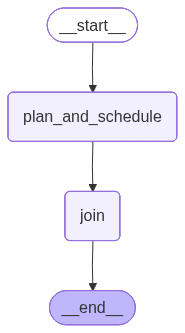

In [26]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

In [27]:
for step in chain.stream([HumanMessage(content=example_question)]):
    print(step)
    print("---")

{'plan_and_schedule': [FunctionMessage(content='Encontrado R$ 754,00 nos Cofrinhos do cliente', additional_kwargs={'idx': 1, 'args': ()}, response_metadata={}, name='cofrinhos_extrato', id='d1b341d9-c35f-4071-8576-ce01479d15ae'), FunctionMessage(content='Recuperado 500 dos Cofrinhos do cliente', additional_kwargs={'idx': 2, 'args': ('500',)}, response_metadata={}, name='cofrinhos_recuperar', id='909cff37-bd84-43f8-a22d-adad60f0b870'), FunctionMessage(content='PIX de 100 enviado para Leonardo', additional_kwargs={'idx': 3, 'args': ('Leonardo', '100')}, response_metadata={}, name='execute_pix', id='31849b8e-3d27-4bd0-b927-3f149cfca331'), FunctionMessage(content='ERROR(Failed to call join with args (). Args resolved to (). Error: TypeError("instantiate_task.<locals>.<lambda>() missing 1 required positional argument: \'x\'"))', additional_kwargs={'idx': 4, 'args': ()}, response_metadata={}, name='join', id='c95857e0-bc13-4dc2-bf09-00ef753b6d81')]}
---
{'join': [AIMessage(content='Thought: 

/Users/leonardojdss/Desktop/projetos/plan-execute-replan-architecture/env/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=JoinOutputs(thought='As o...nviado com sucesso**.')), input_type=JoinOutputs])
  return self.__pydantic_serializer__.to_python(


In [29]:
# Final answer
last_messages = next(iter(step.values()))
print(last_messages[-1].content)


Resgate realizado: recuperei **R$ 500,00** dos seus cofrinhos (você tinha **R$ 754,00** ao todo).

Em seguida, fiz a transferência via **PIX de R$ 100,00 para o Leonardo** — **enviado com sucesso**.
